In [36]:
import pandas as pd
import glob, os
import matplotlib.pyplot as plt

In [ ]:
Ns = [2, 20, 200, 2000, 20000]
means, memory = [], []

for N in Ns:
    base_dir = f"/users/ebrown62/scCODA/sccoda/datasets/results/N={N}"
    csv_files = glob.glob(os.path.join(base_dir, "*/profiling_*.csv"))
    time_vals, mem_vals = [], []
    for f in csv_files:
        df = pd.read_csv(f)
        time_vals.append(df["elapsed_time_seconds"].mean())
        mem_vals.append(df["peak_memory_MB"].mean())

    mean_time = float(round(sum(time_vals) / len(time_vals), 4))
    mean_mem = float(round(sum(mem_vals) / len(mem_vals), 4))
    means.append(mean_time)
    memory.append(mean_mem)


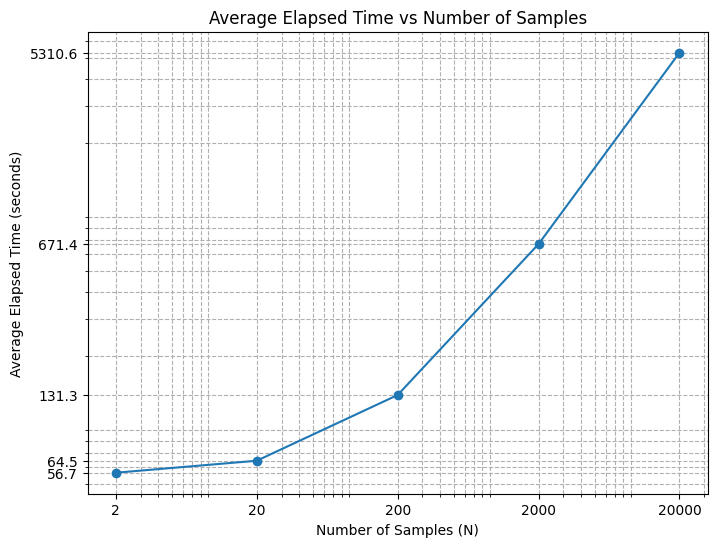

In [38]:
def plot_times(Ns, means):
    plt.figure(figsize=(8, 6))
    plt.plot(Ns, means, marker='o')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Average Elapsed Time (seconds)')
    plt.title('Average Elapsed Time vs Number of Samples')
    plt.grid(True, which="both", ls="--")
    plt.xticks(Ns, [str(n) for n in Ns])
    plt.yticks(means, [f"{m:.1f}" for m in means])
    plt.show()
plot_times(Ns, means)

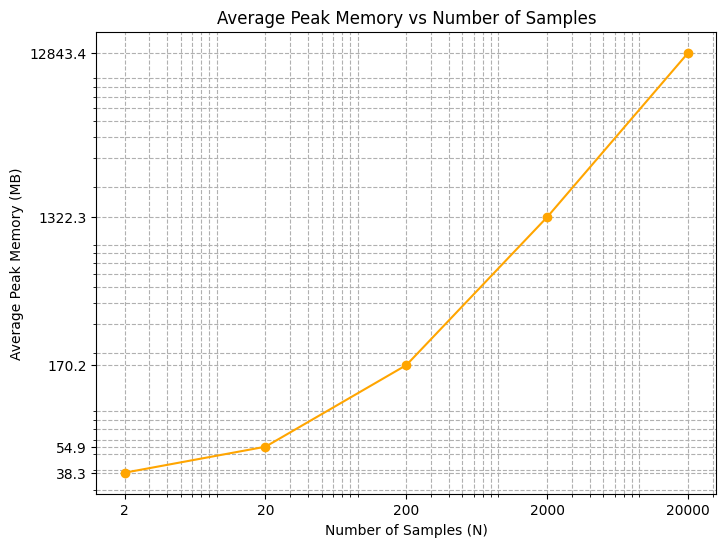

In [39]:
def plot_memory(Ns, memory):
    plt.figure(figsize=(8, 6))
    plt.plot(Ns, memory, marker='o', color='orange')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Number of Samples (N)')
    plt.ylabel('Average Peak Memory (MB)')
    plt.title('Average Peak Memory vs Number of Samples')
    plt.grid(True, which="both", ls="--")
    plt.xticks(Ns, [str(n) for n in Ns]) 
    plt.yticks(memory, [f"{m:.1f}" for m in memory])
    plt.show()
plot_memory(Ns, memory)